Starting Variational EM optimization for 1000 epochs with batch size 50...
Epoch 10/1000, Final Batch ELBO: -144.5333
Epoch 20/1000, Final Batch ELBO: -128.7682
Epoch 30/1000, Final Batch ELBO: -123.1972
Epoch 40/1000, Final Batch ELBO: -27.2085
Epoch 50/1000, Final Batch ELBO: 31.7640
Epoch 60/1000, Final Batch ELBO: -23.7893
Epoch 70/1000, Final Batch ELBO: -50.0704
Epoch 80/1000, Final Batch ELBO: 95.0373
Epoch 90/1000, Final Batch ELBO: 25.9158
Epoch 100/1000, Final Batch ELBO: 48.5048
Epoch 110/1000, Final Batch ELBO: 11.9355
Epoch 120/1000, Final Batch ELBO: 70.7847
Epoch 130/1000, Final Batch ELBO: 50.2971
Epoch 140/1000, Final Batch ELBO: 78.5169
Epoch 150/1000, Final Batch ELBO: 100.5415
Epoch 160/1000, Final Batch ELBO: 62.7439
Epoch 170/1000, Final Batch ELBO: 76.4615
Epoch 180/1000, Final Batch ELBO: -48.0268
Epoch 190/1000, Final Batch ELBO: 61.4678
Epoch 200/1000, Final Batch ELBO: 39.8389
Epoch 210/1000, Final Batch ELBO: 82.3559
Epoch 220/1000, Final Batch ELBO: 131.862

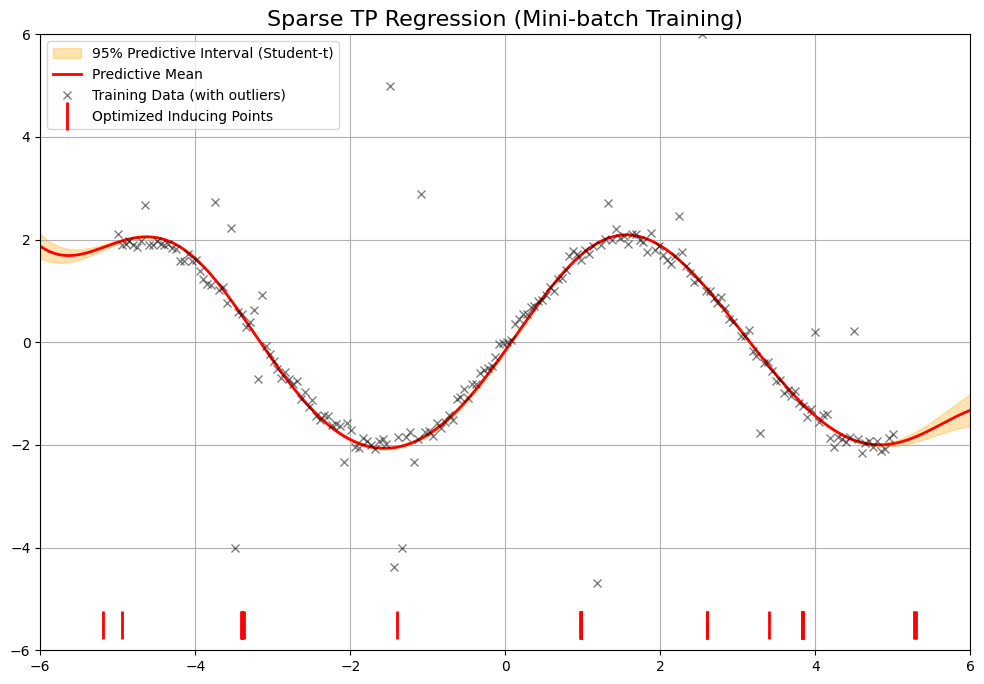

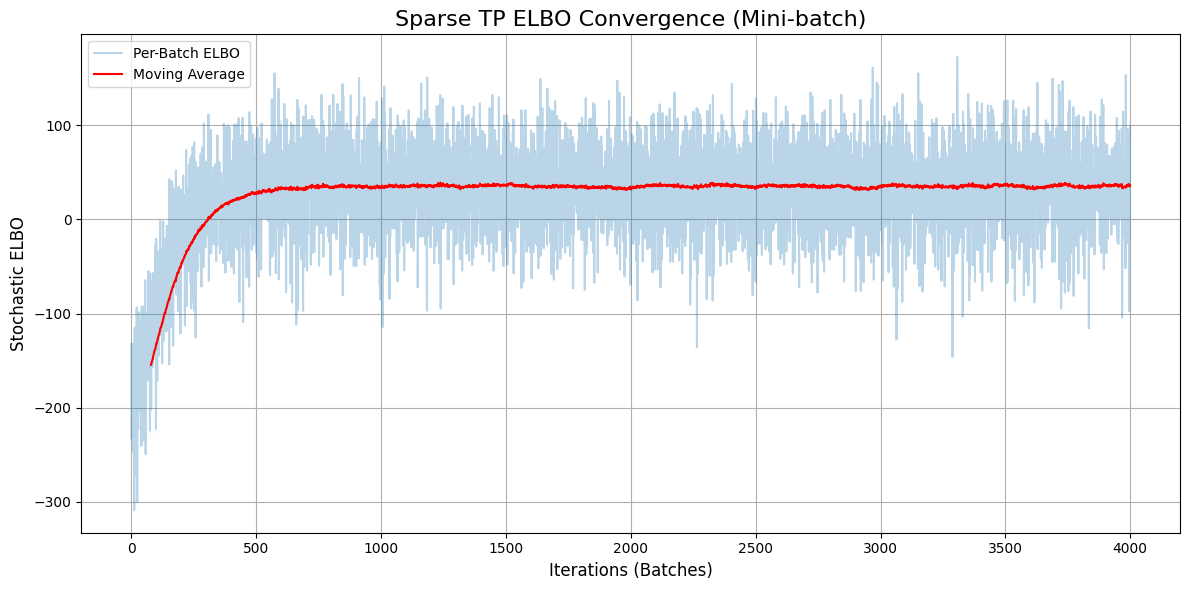

In [ ]:

# import torch
# import torch.nn as nn
# import torch.optim as optim
# import math
# from torch.utils.data import DataLoader, TensorDataset
# import logging

# def rbf_kernel(X1, X2, lengthscale=1.0, variance=1.0):
#     """
#     Computes the RBF kernel matrix between two sets of points.
#     """
#     lengthscale = torch.as_tensor(lengthscale, dtype=X1.dtype, device=X1.device)
#     variance = torch.as_tensor(variance, dtype=X1.dtype, device=X1.device)
#     sqdist = torch.cdist(X1, X2, p=2).pow(2)
#     return variance * torch.exp(-0.5 * sqdist / lengthscale**2)

# # === 事前分布のヘルパークラス (priors.py がない場合) ===
# class GammaPrior:
#     def __init__(self, concentration, rate):
#         self.concentration = concentration
#         self.rate = rate
#     def log_prob(self, x):
#         return (self.concentration - 1.0) * torch.log(x.clamp(min=1e-9)) - self.rate * x

# class LogNormalPrior:
#     def __init__(self, loc, scale):
#         self.loc = loc
#         self.scale = scale
#         self.var = scale**2
#     def log_prob(self, x):
#         log_x = torch.log(x.clamp(min=1e-9))
#         return -log_x - (log_x - self.loc)**2 / (2 * self.var)
# # ====================================================



# class SparseTPRTMiniBatch:
#     """
#     Implementation of Variational EM for Student-t Process Regression with Mini-batching.
#     - E-Step: CAVI updates for variational parameters.
#     - M-Step: Gradient-based optimization of model hyperparameters and inducing points
#               using a stochastic estimate of the ELBO.
#     """
#     def __init__(self, X, y, M, nu_f=2.1, nu_e=2.1, kernel_lengthscale=1.0, kernel_variance=1.0, likelihood_sigma=1.0):
#         """
#         Args:
#             X (torch.Tensor): Full training inputs, shape (N, D).
#             y (torch.Tensor): Full training outputs, shape (N, 1) or (N,).
#             M (int): Number of inducing points.
#             ... (hyperparameters)
#         """
#         self.X_full = X # Keep full data for reference (e.g., initialization)
#         self.y_full = y.view(-1, 1) # Keep full data for reference
#         self.N, self.D = X.shape
#         self.M = M

#         # --- Initialize Inducing Points using Sobol sequence from the full dataset ---
#         Z_initial = self._initialize_inducing_points()
#         self.Z = nn.Parameter(Z_initial)

#         # --- Initialize Hyperparameters (M-step) ---
#         self.log_nu_f = nn.Parameter(torch.log(torch.tensor(nu_f, dtype=X.dtype)))
#         self.log_nu_epsilon = nn.Parameter(torch.log(torch.tensor(nu_e, dtype=X.dtype)))
#         self.log_sigma_sq = nn.Parameter(torch.log(torch.tensor(likelihood_sigma**2, dtype=X.dtype)))
#         self.log_kernel_lengthscale = nn.Parameter(torch.log(torch.tensor(kernel_lengthscale, dtype=X.dtype)))
#         self.log_kernel_variance = nn.Parameter(torch.log(torch.tensor(kernel_variance, dtype=X.dtype)))

#         # === ★ 変更点: 事前分布のインスタンスを定義 ===
#         self.lengthscale_prior = GammaPrior(3.0, 6.0)
#         self.variance_prior = GammaPrior(2.0, 0.15)
#         self.sigma_sq_prior = GammaPrior(1.1, 0.05)
#         self.nu_prior = LogNormalPrior(loc=1.0, scale=1.0)

#         # --- Initialize GLOBAL Variational Parameters (updated across batches) ---
#         self.m_u = torch.zeros(self.M, 1, dtype=X.dtype, device=X.device)
#         self.S_u = torch.eye(self.M, dtype=X.dtype, device=X.device)
#         self.alpha_r = torch.tensor(1.0, dtype=X.dtype, device=X.device)
#         self.beta_r = torch.tensor(1.0, dtype=X.dtype, device=X.device)
#         # LOCAL variational parameters (alpha_lambda, beta_lambda) are computed on-the-fly for each batch

#     def _initialize_inducing_points(self):
#         min_bounds = self.X_full.min(dim=0).values
#         max_bounds = self.X_full.max(dim=0).values
#         sobol_engine = torch.quasirandom.SobolEngine(dimension=self.D, scramble=True, seed=0)
#         sobol_points_unit = sobol_engine.draw(self.M).to(self.X_full.dtype)
#         return min_bounds + sobol_points_unit * (max_bounds - min_bounds)

#     def _get_hyperparams(self):
#         return {
#             "nu_f": torch.exp(self.log_nu_f),
#             "nu_epsilon": torch.exp(self.log_nu_epsilon),
#             "sigma_sq": torch.exp(self.log_sigma_sq),
#             "lengthscale": torch.exp(self.log_kernel_lengthscale),
#             "variance": torch.exp(self.log_kernel_variance)
#         }

#     # === E-Step Methods (now operate on a batch) ===
#     def _update_q_lambda(self, y_batch, params, L_ZZ, K_XZ_batch, K_ZX_batch, k_ii_batch):
#         KZZ_inv_m_u = torch.cholesky_solve(self.m_u, L_ZZ)
#         expected_f_mean = K_XZ_batch @ KZZ_inv_m_u # Shape: (B, 1)

#         if self.alpha_r > 1: expected_r_inv = self.beta_r / (self.alpha_r - 1.0)
#         else: expected_r_inv = self.beta_r

#         KXZ_KZZ_inv = torch.cholesky_solve(K_ZX_batch, L_ZZ).T
#         var_f_term1 = expected_r_inv * (k_ii_batch - (KXZ_KZZ_inv * K_XZ_batch).sum(dim=1))
#         var_f_term2 = (KXZ_KZZ_inv @ self.S_u * KXZ_KZZ_inv).sum(dim=1)
#         var_f = (var_f_term1 + var_f_term2).unsqueeze(1) # Shape: (B, 1)

#         expected_sq_error = (y_batch - expected_f_mean).pow(2) + var_f
#         alpha_lambda_batch = params['nu_epsilon'] / 2.0 + 0.5
#         beta_lambda_batch = params['nu_epsilon'] / 2.0 + (0.5 / params['sigma_sq']) * expected_sq_error
#         return alpha_lambda_batch, beta_lambda_batch

#     def _update_q_r(self, params, L_ZZ):
#         trace_term = torch.trace(torch.cholesky_solve(self.S_u, L_ZZ))
#         KZZ_inv_m_u = torch.cholesky_solve(self.m_u, L_ZZ)
#         mean_term = self.m_u.T @ KZZ_inv_m_u
#         expected_u_quadratic_form = trace_term + mean_term
#         self.alpha_r = params['nu_f'] / 2.0 + self.M / 2.0
#         self.beta_r = params['nu_f'] / 2.0 + 0.5 * expected_u_quadratic_form.squeeze()

#     def _update_q_u(self, y_batch, alpha_lambda_batch, beta_lambda_batch, params, K_ZZ, K_XZ_batch, K_ZX_batch):
#         expected_r = self.alpha_r / self.beta_r
#         expected_lambda = alpha_lambda_batch.squeeze() / beta_lambda_batch.squeeze()
#         c = expected_lambda / params['sigma_sq']

#         B = (K_ZX_batch * c) @ K_XZ_batch
#         precision_inner = expected_r * K_ZZ + B
#         L_precision_inner = torch.linalg.cholesky(precision_inner + torch.eye(self.M, dtype=K_ZZ.dtype, device=K_ZZ.device) * 1e-6)

#         tmp_S = torch.cholesky_solve(K_ZZ, L_precision_inner)
#         self.S_u = K_ZZ @ tmp_S

#         y_term = K_ZX_batch @ (y_batch.squeeze() * c)
#         m_u_unscaled = torch.cholesky_solve(y_term.unsqueeze(1), L_precision_inner)
#         self.m_u = K_ZZ @ m_u_unscaled

#     def _cavi_step(self, X_batch, y_batch, params, K_ZZ, L_ZZ, cavi_max_iter):
#         # Kernels relevant to the batch
#         K_XZ_batch = rbf_kernel(X_batch, self.Z, params['lengthscale'], params['variance'])
#         K_ZX_batch = K_XZ_batch.T
#         k_ii_batch = params['variance'].expand(X_batch.shape[0])

#         # Local vars for lambda are re-calculated each time
#         alpha_lambda_batch, beta_lambda_batch = None, None

#         for _ in range(cavi_max_iter):
#             alpha_lambda_batch, beta_lambda_batch = self._update_q_lambda(y_batch, params, L_ZZ, K_XZ_batch, K_ZX_batch, k_ii_batch)
#             self._update_q_r(params, L_ZZ) # Depends on global S_u, m_u
#             self._update_q_u(y_batch, alpha_lambda_batch, beta_lambda_batch, params, K_ZZ, K_XZ_batch, K_ZX_batch) # Uses batch data

#         return alpha_lambda_batch, beta_lambda_batch


#     def _e_step(self, X_batch, y_batch, cavi_max_iter=10, cavi_tol=1e-5):
#         with torch.no_grad():
#             params = self._get_hyperparams()
#             K_ZZ = rbf_kernel(self.Z, self.Z, params['lengthscale'], params['variance']) + torch.eye(self.M, device=self.Z.device) * 1e-6
#             L_ZZ = torch.linalg.cholesky(K_ZZ)
            
#             # Perform CAVI for the current batch, updating global (m_u, S_u, etc.) and getting local params
#             alpha_lambda_batch, beta_lambda_batch = self._cavi_step(X_batch, y_batch, params, K_ZZ, L_ZZ, cavi_max_iter)

#         return alpha_lambda_batch, beta_lambda_batch


#     # === M-Step Methods (now operate on a batch) ===
#     def _m_step(self, optimizer, X_batch, y_batch, alpha_lambda_batch, beta_lambda_batch):
#         optimizer.zero_grad()
#         # Pass batch-specific variational parameters to ELBO calculation
#         elbo = self._calculate_elbo(X_batch, y_batch, alpha_lambda_batch, beta_lambda_batch)
#         loss = -elbo
#         loss.backward()
#         optimizer.step()
#         return elbo.item()
    
#     def _calculate_elbo(self, X_batch, y_batch, alpha_lambda_batch, beta_lambda_batch):
#         B = X_batch.shape[0] # Batch size
#         params = self._get_hyperparams()
        
#         K_ZZ = rbf_kernel(self.Z, self.Z, params['lengthscale'], params['variance']) + torch.eye(self.M, device=self.Z.device) * 1e-6
#         L_ZZ = torch.linalg.cholesky(K_ZZ)
#         K_XZ_batch = rbf_kernel(X_batch, self.Z, params['lengthscale'], params['variance'])
#         K_ZX_batch = K_XZ_batch.T
#         k_ii_batch = params['variance'].expand(B)
        
#         # --- 1. Expected Log-Likelihood (Data-dependent term) ---
#         expected_log_lambda = torch.digamma(alpha_lambda_batch) - torch.log(beta_lambda_batch)
#         expected_lambda = alpha_lambda_batch / beta_lambda_batch
        
#         KZZ_inv_m_u = torch.cholesky_solve(self.m_u, L_ZZ)
#         expected_f_mean = K_XZ_batch @ KZZ_inv_m_u

#         if self.alpha_r > 1: expected_r_inv = self.beta_r / (self.alpha_r - 1.0)
#         else: expected_r_inv = self.beta_r
        
#         KXZ_KZZ_inv = torch.cholesky_solve(K_ZX_batch, L_ZZ).T
#         var_f_term1 = expected_r_inv * (k_ii_batch - (KXZ_KZZ_inv * K_XZ_batch).sum(dim=1))
#         var_f_term2 = (KXZ_KZZ_inv @ self.S_u * KXZ_KZZ_inv).sum(dim=1)
#         var_f = (var_f_term1 + var_f_term2).unsqueeze(1)
        
#         expected_sq_error = (y_batch - expected_f_mean).pow(2) + var_f
        
#         log_lik_batch = 0.5 * torch.sum(expected_log_lambda - math.log(2 * math.pi) - torch.log(params['sigma_sq']) - \
#                                   (expected_lambda / params['sigma_sq']) * expected_sq_error)
        
#         # ★★★ SCALE DATA-DEPENDENT TERM ★★★
#         log_lik = log_lik_batch * (self.N / B)

#         # --- 2. KL Divergences ---
#         # KL[q(r) || p(r)] (Global term, NOT scaled)
#         p_alpha_r, p_beta_r = params['nu_f'] / 2.0, params['nu_f'] / 2.0
#         kl_r = (self.alpha_r - p_alpha_r) * torch.digamma(self.alpha_r) - torch.lgamma(self.alpha_r) + torch.lgamma(p_alpha_r) + \
#                p_alpha_r * (torch.log(self.beta_r) - torch.log(p_beta_r)) + self.alpha_r * (p_beta_r - self.beta_r) / self.beta_r
        
#         # KL[q(u) || p(u)] (Global term, NOT scaled)
#         expected_log_r = torch.digamma(self.alpha_r) - torch.log(self.beta_r)
#         expected_r = self.alpha_r / self.beta_r
        
#         L_S = torch.linalg.cholesky(self.S_u + torch.eye(self.M, dtype=self.S_u.dtype, device=self.S_u.device) * 1e-6)
#         logdet_S_u = 2 * torch.sum(torch.log(torch.diag(L_S)))
#         logdet_K_ZZ = 2 * torch.sum(torch.log(torch.diag(L_ZZ)))
#         trace_KZZinv_Su = torch.trace(torch.cholesky_solve(self.S_u, L_ZZ))
#         m_T_KZZinv_m = self.m_u.T @ KZZ_inv_m_u
#         expected_u_quadratic = trace_KZZinv_Su + m_T_KZZinv_m
        
#         kl_u = 0.5 * (-logdet_S_u - self.M * expected_log_r + logdet_K_ZZ + expected_r * expected_u_quadratic - self.M).squeeze()
        
#         # KL[q(lambda) || p(lambda)] (Data-dependent term)
#         p_alpha_lambda, p_beta_lambda = params['nu_epsilon'] / 2.0, params['nu_epsilon'] / 2.0
#         kl_lambda_batch = torch.sum((alpha_lambda_batch - p_alpha_lambda) * torch.digamma(alpha_lambda_batch) - \
#                     torch.lgamma(alpha_lambda_batch) + torch.lgamma(p_alpha_lambda) + \
#                     p_alpha_lambda * (torch.log(beta_lambda_batch) - torch.log(p_beta_lambda)) + \
#                     alpha_lambda_batch * (p_beta_lambda - beta_lambda_batch) / beta_lambda_batch)
        
#         # ★★★ SCALE DATA-DEPENDENT TERM ★★★
#         kl_lambda = kl_lambda_batch * (self.N / B)

#         #################################################ç
#         #################################################ç
#         #################################################ç
#         #################################################ç
#         #################################################ç
#         #################################################ç
#         # Calculate log prior for hyperparameters
#         params = self._get_hyperparams()
#         log_prior = 0.0
#         log_prior += self.lengthscale_prior.log_prob(params['lengthscale'])
#         log_prior += self.variance_prior.log_prob(params['variance'])
#         log_prior += self.sigma_sq_prior.log_prob(params['sigma_sq'])
#         log_prior += self.nu_prior.log_prob(params['nu_f'])
#         log_prior += self.nu_prior.log_prob(params['nu_epsilon'])

#         return log_lik - kl_u - kl_r - kl_lambda

#     def fit(self, epochs=100, batch_size=64, cavi_max_iter=5, lr=0.01):
#         """Runs the full Variational EM algorithm using mini-batches."""
#         parameters_to_optimize = [
#             self.log_nu_f, self.log_nu_epsilon, self.log_sigma_sq,
#             self.log_kernel_lengthscale, self.log_kernel_variance, self.Z
#         ]
#         optimizer = optim.Adam(parameters_to_optimize, lr=lr)
        
#         # Create DataLoader for mini-batching
#         dataset = TensorDataset(self.X_full, self.y_full)
#         dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
        
#         elbo_history = []
#         print(f"Starting Variational EM optimization for {epochs} epochs with batch size {batch_size}...")
#         for epoch in range(epochs):
#             for i, (X_batch, y_batch) in enumerate(dataloader):

#                 # print(f"Processing batch {i+1}/{len(dataloader)} in epoch {epoch+1}...")

#                 # E-Step: Update global variational params and get local ones for the batch
#                 alpha_lambda_batch, beta_lambda_batch = self._e_step(X_batch, y_batch, cavi_max_iter=cavi_max_iter)
                
#                 # M-Step: Update hyperparameters using the stochastic ELBO from the batch
#                 elbo = self._m_step(optimizer, X_batch, y_batch, alpha_lambda_batch, beta_lambda_batch)
                
#                 elbo_history.append(elbo)
            
#             if (epoch + 1) % 10 == 0:
#                 print(f"Epoch {epoch+1}/{epochs}, Final Batch ELBO: {elbo:.4f}")
        
#         print("\nOptimization finished.")
#         return elbo_history

#     def predict(self, X_test):
#         """
#         Makes predictions for new data X_test. (No changes needed here)
#         """
#         with torch.no_grad():
#             params = self._get_hyperparams()
            
#             K_ZZ = rbf_kernel(self.Z, self.Z, params['lengthscale'], params['variance']) + torch.eye(self.M, device=self.Z.device) * 1e-6
#             L_ZZ = torch.linalg.cholesky(K_ZZ)
#             K_star_Z = rbf_kernel(X_test, self.Z, params['lengthscale'], params['variance'])
#             k_star_star = rbf_kernel(X_test, X_test, params['lengthscale'], params['variance']).diag()

#             KZZ_inv_m_u = torch.cholesky_solve(self.m_u, L_ZZ)
#             pred_mean = K_star_Z @ KZZ_inv_m_u

#             K_star_Z_K_ZZ_inv = torch.cholesky_solve(K_star_Z.T, L_ZZ, upper=False).T
            
#             gp_var = k_star_star - (K_star_Z_K_ZZ_inv * K_star_Z).sum(dim=1) + \
#                      (K_star_Z_K_ZZ_inv @ self.S_u * K_star_Z_K_ZZ_inv).sum(dim=1)
            
#             pred_nu = 2 * self.alpha_r
#             pred_scale_sq = (gp_var * (self.beta_r / self.alpha_r)).unsqueeze(1)
            
#             return pred_mean, pred_scale_sq, pred_nu
        




        
# if __name__ == '__main__':

#     import matplotlib.pyplot as plt
#     from scipy.stats import t
#     import pandas as pd

#     torch.set_default_dtype(torch.float64)
#     torch.manual_seed(41)

#     # --- 1. 1次元データの生成 ---
#     N = 200 # Increase data size for mini-batching to be more meaningful
#     X_train = torch.linspace(-5, 5, N).unsqueeze(1)
#     y_true = torch.sin(X_train) * 2
    
#     noise = torch.randn(N, 1) * 0.1
#     t_dist_sample = torch.distributions.StudentT(df=2)
#     outlier_noise = t_dist_sample.sample((N, 1)) * 0.5
#     y_train = y_true + noise
#     outlier_indices = torch.randperm(N)[:20] # More outliers
#     y_train[outlier_indices] += outlier_noise[outlier_indices] * 3
#     y_train[30] = -4.0
#     y_train[70] = 5.0
#     y_train[150] = 6.0

#     # --- 2. モデルのセットアップ ---
#     M = 50 # Number of inducing points
    
#     # Instantiate the new Mini-batch model
#     model = SparseTPRTMiniBatch(
#         X=X_train,
#         y=y_train,
#         M=M,
#         nu_f=5.0,
#         nu_e=5.0,
#         kernel_lengthscale=0.5,
#         kernel_variance=2.0,
#         likelihood_sigma=0.5
#     )

#     # --- 3. モデルの学習 ---
#     elbo_history = model.fit(epochs=1000, batch_size=50, cavi_max_iter=20, lr=0.01)

#     # --- 4. 予測の実行 ---
#     X_test = torch.linspace(-6, 6, 200).unsqueeze(1)
#     pred_mean, pred_var, pred_nu = model.predict(X_test)

#     # --- 5. 回帰結果の可視化 ---
#     plt.figure(figsize=(12, 8))
#     pred_scale = torch.sqrt(pred_var.clamp(min=1e-9))
#     df = pred_nu.item()
#     lower_quantile = t.ppf(0.025, df=df)
#     upper_quantile = t.ppf(0.975, df=df)
#     lower = pred_mean + lower_quantile * pred_scale
#     upper = pred_mean + upper_quantile * pred_scale

#     plt.fill_between(X_test.squeeze(), lower.squeeze(), upper.squeeze(), color='orange', alpha=0.3, label='95% Predictive Interval (Student-t)')
#     plt.plot(X_test, pred_mean, 'r-', lw=2, label='Predictive Mean')
#     plt.plot(X_train, y_train, 'kx', mew=1, alpha=0.5, label='Training Data (with outliers)')
#     plt.plot(model.Z.detach(), torch.full_like(model.Z.detach(), -5.5), 'r|', ms=20, mew=2, label='Optimized Inducing Points')
#     plt.title('Sparse TP Regression (Mini-batch Training)', fontsize=16)
#     plt.legend(loc='upper left')
#     plt.grid(True)
#     plt.xlim(-6, 6)
#     plt.ylim(-6, 6)
    
#     # --- 6. ELBOの履歴を可視化 ---
#     plt.figure(figsize=(12, 6))
#     # Plot a moving average of the ELBO to see the trend more clearly
#     elbo_series = pd.Series(elbo_history)
#     elbo_moving_avg = elbo_series.rolling(window=len(elbo_history) // 50).mean() # window size is num_batches
#     plt.plot(elbo_history, alpha=0.3, label='Per-Batch ELBO')
#     plt.plot(elbo_moving_avg, color='red', label='Moving Average')
#     plt.title('Sparse TP ELBO Convergence (Mini-batch)', fontsize=16)
#     plt.xlabel('Iterations (Batches)', fontsize=12)
#     plt.ylabel('Stochastic ELBO', fontsize=12)
#     plt.grid(True)
#     plt.legend()
#     plt.tight_layout()

#     plt.show()

Starting Variational EM optimization for 100 epochs with batch size 50...
Epoch 10/100, Final Batch ELBO: -241.6329
Epoch 20/100, Final Batch ELBO: -120.8077
Epoch 30/100, Final Batch ELBO: -122.6349
Epoch 40/100, Final Batch ELBO: -100.3965
Epoch 50/100, Final Batch ELBO: -41.2682
Epoch 60/100, Final Batch ELBO: -0.1816
Epoch 70/100, Final Batch ELBO: -0.6758
Epoch 80/100, Final Batch ELBO: -18.3772
Epoch 90/100, Final Batch ELBO: -64.3670
Epoch 100/100, Final Batch ELBO: 22.4748

Optimization finished.


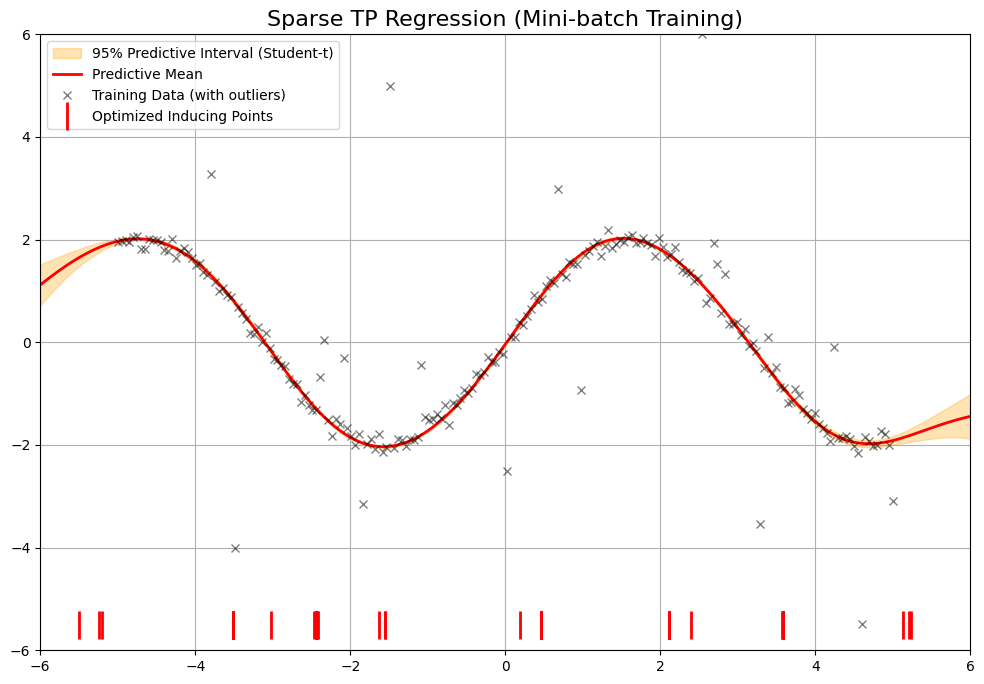

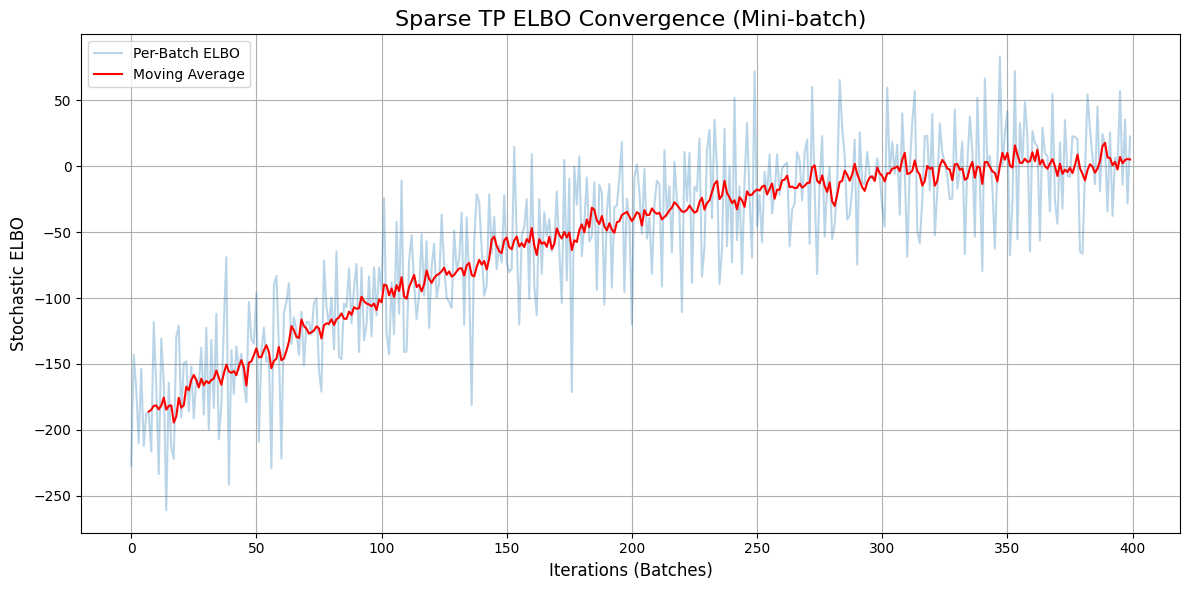

In [5]:

import torch
import torch.nn as nn
import torch.optim as optim
import math
from torch.utils.data import DataLoader, TensorDataset
import logging

def rbf_kernel(X1, X2, lengthscale=1.0, variance=1.0):
    """
    Computes the RBF kernel matrix between two sets of points.
    """
    lengthscale = torch.as_tensor(lengthscale, dtype=X1.dtype, device=X1.device)
    variance = torch.as_tensor(variance, dtype=X1.dtype, device=X1.device)
    sqdist = torch.cdist(X1, X2, p=2).pow(2)
    return variance * torch.exp(-0.5 * sqdist / lengthscale**2)

# === 事前分布のヘルパークラス (priors.py がない場合) ===
class GammaPrior:
    def __init__(self, concentration, rate):
        self.concentration = concentration
        self.rate = rate
    def log_prob(self, x):
        return (self.concentration - 1.0) * torch.log(x.clamp(min=1e-9)) - self.rate * x

class LogNormalPrior:
    def __init__(self, loc, scale):
        self.loc = loc
        self.scale = scale
        self.var = scale**2
    def log_prob(self, x):
        log_x = torch.log(x.clamp(min=1e-9))
        return -log_x - (log_x - self.loc)**2 / (2 * self.var)
# ====================================================



class SparseTPRTMiniBatch:
    """
    Implementation of Variational EM for Student-t Process Regression with Mini-batching.
    - E-Step: CAVI updates for variational parameters.
    - M-Step: Gradient-based optimization of model hyperparameters and inducing points
              using a stochastic estimate of the ELBO.
    """
    def __init__(self, X, y, M, nu_f=2.1, nu_e=2.1, kernel_lengthscale=1.0, kernel_variance=1.0, likelihood_sigma=1.0):
        """
        Args:
            X (torch.Tensor): Full training inputs, shape (N, D).
            y (torch.Tensor): Full training outputs, shape (N, 1) or (N,).
            M (int): Number of inducing points.
            ... (hyperparameters)
        """
        self.X_full = X # Keep full data for reference (e.g., initialization)
        self.y_full = y.view(-1, 1) # Keep full data for reference
        self.N, self.D = X.shape
        self.M = M

        # --- Initialize Inducing Points using Sobol sequence from the full dataset ---
        Z_initial = self._initialize_inducing_points()
        self.Z = nn.Parameter(Z_initial)

        # --- Initialize Hyperparameters (M-step) ---
        self.log_nu_f = nn.Parameter(torch.log(torch.tensor(nu_f, dtype=X.dtype)))
        self.log_nu_epsilon = nn.Parameter(torch.log(torch.tensor(nu_e, dtype=X.dtype)))
        self.log_sigma_sq = nn.Parameter(torch.log(torch.tensor(likelihood_sigma**2, dtype=X.dtype)))
        self.log_kernel_lengthscale = nn.Parameter(torch.log(torch.tensor(kernel_lengthscale, dtype=X.dtype)))
        self.log_kernel_variance = nn.Parameter(torch.log(torch.tensor(kernel_variance, dtype=X.dtype)))

        # === ★ 変更点: 事前分布のインスタンスを定義 ===
        self.lengthscale_prior = GammaPrior(3.0, 6.0)
        self.variance_prior = GammaPrior(2.0, 0.15)
        self.sigma_sq_prior = GammaPrior(1.1, 0.05)
        self.nu_prior = LogNormalPrior(loc=1.0, scale=1.0)

        # --- Initialize GLOBAL Variational Parameters (updated across batches) ---
        self.m_u = torch.zeros(self.M, 1, dtype=X.dtype, device=X.device)
        self.S_u = torch.eye(self.M, dtype=X.dtype, device=X.device)
        self.alpha_r = torch.tensor(1.0, dtype=X.dtype, device=X.device)
        self.beta_r = torch.tensor(1.0, dtype=X.dtype, device=X.device)
        # LOCAL variational parameters (alpha_lambda, beta_lambda) are computed on-the-fly for each batch

    def _initialize_inducing_points(self):
        min_bounds = self.X_full.min(dim=0).values
        max_bounds = self.X_full.max(dim=0).values
        sobol_engine = torch.quasirandom.SobolEngine(dimension=self.D, scramble=True, seed=0)
        sobol_points_unit = sobol_engine.draw(self.M).to(self.X_full.dtype)
        return min_bounds + sobol_points_unit * (max_bounds - min_bounds)

    def _get_hyperparams(self):
        return {
            "nu_f": torch.exp(self.log_nu_f),
            "nu_epsilon": torch.exp(self.log_nu_epsilon),
            "sigma_sq": torch.exp(self.log_sigma_sq),
            "lengthscale": torch.exp(self.log_kernel_lengthscale),
            "variance": torch.exp(self.log_kernel_variance)
        }

    # === E-Step Methods (now operate on a batch) ===
    def _update_q_lambda(self, y_batch, params, L_ZZ, K_XZ_batch, K_ZX_batch, k_ii_batch):
        KZZ_inv_m_u = torch.cholesky_solve(self.m_u, L_ZZ)
        expected_f_mean = K_XZ_batch @ KZZ_inv_m_u # Shape: (B, 1)

        if self.alpha_r > 1: expected_r_inv = self.beta_r / (self.alpha_r - 1.0)
        else: expected_r_inv = self.beta_r

        KXZ_KZZ_inv = torch.cholesky_solve(K_ZX_batch, L_ZZ).T
        var_f_term1 = expected_r_inv * (k_ii_batch - (KXZ_KZZ_inv * K_XZ_batch).sum(dim=1))
        var_f_term2 = (KXZ_KZZ_inv @ self.S_u * KXZ_KZZ_inv).sum(dim=1)
        var_f = (var_f_term1 + var_f_term2).unsqueeze(1) # Shape: (B, 1)

        expected_sq_error = (y_batch - expected_f_mean).pow(2) + var_f
        alpha_lambda_batch = params['nu_epsilon'] / 2.0 + 0.5
        beta_lambda_batch = params['nu_epsilon'] / 2.0 + (0.5 / params['sigma_sq']) * expected_sq_error
        return alpha_lambda_batch, beta_lambda_batch

    def _update_q_r(self, params, L_ZZ):
        trace_term = torch.trace(torch.cholesky_solve(self.S_u, L_ZZ))
        KZZ_inv_m_u = torch.cholesky_solve(self.m_u, L_ZZ)
        mean_term = self.m_u.T @ KZZ_inv_m_u
        expected_u_quadratic_form = trace_term + mean_term
        self.alpha_r = params['nu_f'] / 2.0 + self.M / 2.0
        self.beta_r = params['nu_f'] / 2.0 + 0.5 * expected_u_quadratic_form.squeeze()

    def _update_q_u(self, y_batch, alpha_lambda_batch, beta_lambda_batch, params, K_ZZ, K_XZ_batch, K_ZX_batch):
        expected_r = self.alpha_r / self.beta_r
        expected_lambda = alpha_lambda_batch.squeeze() / beta_lambda_batch.squeeze()
        c = expected_lambda / params['sigma_sq']

        B = (K_ZX_batch * c) @ K_XZ_batch
        precision_inner = expected_r * K_ZZ + B
        L_precision_inner = torch.linalg.cholesky(precision_inner + torch.eye(self.M, dtype=K_ZZ.dtype, device=K_ZZ.device) * 1e-6)

        tmp_S = torch.cholesky_solve(K_ZZ, L_precision_inner)
        self.S_u = K_ZZ @ tmp_S

        y_term = K_ZX_batch @ (y_batch.squeeze() * c)
        m_u_unscaled = torch.cholesky_solve(y_term.unsqueeze(1), L_precision_inner)
        self.m_u = K_ZZ @ m_u_unscaled

    def _cavi_step(self, X_batch, y_batch, params, K_ZZ, L_ZZ, cavi_max_iter, cavi_tol):
        # Kernels relevant to the batch
        K_XZ_batch = rbf_kernel(X_batch, self.Z, params['lengthscale'], params['variance'])
        K_ZX_batch = K_XZ_batch.T
        k_ii_batch = params['variance'].expand(X_batch.shape[0])

        # Local vars for lambda are re-calculated each time
        alpha_lambda_batch, beta_lambda_batch = None, None

        for _ in range(cavi_max_iter):
            m_u_old, S_u_old = self.m_u.clone(), self.S_u.clone()
            alpha_lambda_batch, beta_lambda_batch = self._update_q_lambda(y_batch, params, L_ZZ, K_XZ_batch, K_ZX_batch, k_ii_batch)
            self._update_q_r(params, L_ZZ) # Depends on global S_u, m_u
            self._update_q_u(y_batch, alpha_lambda_batch, beta_lambda_batch, params, K_ZZ, K_XZ_batch, K_ZX_batch) # Uses batch data
            m_u_change = torch.norm(self.m_u - m_u_old) / (torch.norm(m_u_old) + 1e-9)
            S_u_change = torch.norm(self.S_u - S_u_old, p='fro') / (torch.norm(S_u_old, p='fro') + 1e-9)
            if m_u_change < cavi_tol and S_u_change < cavi_tol:
                break

        return alpha_lambda_batch, beta_lambda_batch

    def _e_step(self, X_batch, y_batch, cavi_max_iter=10, cavi_tol=1e-5):
        with torch.no_grad():
            params = self._get_hyperparams()
            K_ZZ = rbf_kernel(self.Z, self.Z, params['lengthscale'], params['variance']) + torch.eye(self.M, device=self.Z.device) * 1e-6
            L_ZZ = torch.linalg.cholesky(K_ZZ)
            
            # Perform CAVI for the current batch, updating global (m_u, S_u, etc.) and getting local params
            alpha_lambda_batch, beta_lambda_batch = self._cavi_step(X_batch, y_batch, params, K_ZZ, L_ZZ, cavi_max_iter, cavi_tol)

        return alpha_lambda_batch, beta_lambda_batch

    # === M-Step Methods (now operate on a batch) ===
    def _m_step(self, optimizer, X_batch, y_batch, alpha_lambda_batch, beta_lambda_batch):
        optimizer.zero_grad()
        # Pass batch-specific variational parameters to ELBO calculation
        elbo = self._calculate_elbo(X_batch, y_batch, alpha_lambda_batch, beta_lambda_batch)
        loss = -elbo
        loss.backward()
        optimizer.step()
        return elbo.item()
    
    def _calculate_elbo(self, X_batch, y_batch, alpha_lambda_batch, beta_lambda_batch):
        B = X_batch.shape[0] # Batch size
        params = self._get_hyperparams()
        
        K_ZZ = rbf_kernel(self.Z, self.Z, params['lengthscale'], params['variance']) + torch.eye(self.M, device=self.Z.device) * 1e-6
        L_ZZ = torch.linalg.cholesky(K_ZZ)
        K_XZ_batch = rbf_kernel(X_batch, self.Z, params['lengthscale'], params['variance'])
        K_ZX_batch = K_XZ_batch.T
        k_ii_batch = params['variance'].expand(B)
        
        # --- 1. Expected Log-Likelihood (Data-dependent term) ---
        expected_log_lambda = torch.digamma(alpha_lambda_batch) - torch.log(beta_lambda_batch)
        expected_lambda = alpha_lambda_batch / beta_lambda_batch
        
        KZZ_inv_m_u = torch.cholesky_solve(self.m_u, L_ZZ)
        expected_f_mean = K_XZ_batch @ KZZ_inv_m_u

        if self.alpha_r > 1: expected_r_inv = self.beta_r / (self.alpha_r - 1.0)
        else: expected_r_inv = self.beta_r
        
        KXZ_KZZ_inv = torch.cholesky_solve(K_ZX_batch, L_ZZ).T
        var_f_term1 = expected_r_inv * (k_ii_batch - (KXZ_KZZ_inv * K_XZ_batch).sum(dim=1))
        var_f_term2 = (KXZ_KZZ_inv @ self.S_u * KXZ_KZZ_inv).sum(dim=1)
        var_f = (var_f_term1 + var_f_term2).unsqueeze(1)
        
        expected_sq_error = (y_batch - expected_f_mean).pow(2) + var_f
        
        log_lik_batch = 0.5 * torch.sum(expected_log_lambda - math.log(2 * math.pi) - torch.log(params['sigma_sq']) - \
                                  (expected_lambda / params['sigma_sq']) * expected_sq_error)
        
        # ★★★ SCALE DATA-DEPENDENT TERM ★★★
        log_lik = log_lik_batch * (self.N / B)

        # --- 2. KL Divergences ---
        # KL[q(r) || p(r)] (Global term, NOT scaled)
        p_alpha_r, p_beta_r = params['nu_f'] / 2.0, params['nu_f'] / 2.0
        kl_r = (self.alpha_r - p_alpha_r) * torch.digamma(self.alpha_r) - torch.lgamma(self.alpha_r) + torch.lgamma(p_alpha_r) + \
               p_alpha_r * (torch.log(self.beta_r) - torch.log(p_beta_r)) + self.alpha_r * (p_beta_r - self.beta_r) / self.beta_r
        
        # KL[q(u) || p(u)] (Global term, NOT scaled)
        expected_log_r = torch.digamma(self.alpha_r) - torch.log(self.beta_r)
        expected_r = self.alpha_r / self.beta_r
        
        L_S = torch.linalg.cholesky(self.S_u + torch.eye(self.M, dtype=self.S_u.dtype, device=self.S_u.device) * 1e-6)
        logdet_S_u = 2 * torch.sum(torch.log(torch.diag(L_S)))
        logdet_K_ZZ = 2 * torch.sum(torch.log(torch.diag(L_ZZ)))
        trace_KZZinv_Su = torch.trace(torch.cholesky_solve(self.S_u, L_ZZ))
        m_T_KZZinv_m = self.m_u.T @ KZZ_inv_m_u
        expected_u_quadratic = trace_KZZinv_Su + m_T_KZZinv_m
        
        kl_u = 0.5 * (-logdet_S_u - self.M * expected_log_r + logdet_K_ZZ + expected_r * expected_u_quadratic - self.M).squeeze()
        
        # KL[q(lambda) || p(lambda)] (Data-dependent term)
        p_alpha_lambda, p_beta_lambda = params['nu_epsilon'] / 2.0, params['nu_epsilon'] / 2.0
        kl_lambda_batch = torch.sum((alpha_lambda_batch - p_alpha_lambda) * torch.digamma(alpha_lambda_batch) - \
                    torch.lgamma(alpha_lambda_batch) + torch.lgamma(p_alpha_lambda) + \
                    p_alpha_lambda * (torch.log(beta_lambda_batch) - torch.log(p_beta_lambda)) + \
                    alpha_lambda_batch * (p_beta_lambda - beta_lambda_batch) / beta_lambda_batch)
        
        # ★★★ SCALE DATA-DEPENDENT TERM ★★★
        kl_lambda = kl_lambda_batch * (self.N / B)

        #################################################ç
        #################################################ç
        #################################################ç
        #################################################ç
        #################################################ç
        #################################################ç
        # Calculate log prior for hyperparameters
        params = self._get_hyperparams()
        log_prior = 0.0
        log_prior += self.lengthscale_prior.log_prob(params['lengthscale'])
        log_prior += self.variance_prior.log_prob(params['variance'])
        log_prior += self.sigma_sq_prior.log_prob(params['sigma_sq'])
        log_prior += self.nu_prior.log_prob(params['nu_f'])
        log_prior += self.nu_prior.log_prob(params['nu_epsilon'])

        return log_lik - kl_u - kl_r - kl_lambda + log_prior

    def fit(self, epochs=100, batch_size=64, cavi_max_iter=5, lr=0.01, cavi_tol=1e-5):
        """Runs the full Variational EM algorithm using mini-batches."""
        parameters_to_optimize = [
            self.log_nu_f, self.log_nu_epsilon, self.log_sigma_sq,
            self.log_kernel_lengthscale, self.log_kernel_variance, self.Z
        ]
        optimizer = optim.Adam(parameters_to_optimize, lr=lr)
        
        # Create DataLoader for mini-batching
        dataset = TensorDataset(self.X_full, self.y_full)
        dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
        
        elbo_history = []
        print(f"Starting Variational EM optimization for {epochs} epochs with batch size {batch_size}...")
        for epoch in range(epochs):
            for i, (X_batch, y_batch) in enumerate(dataloader):

                # print(f"Processing batch {i+1}/{len(dataloader)} in epoch {epoch+1}...")

                # E-Step: Update global variational params and get local ones for the batch
                alpha_lambda_batch, beta_lambda_batch = self._e_step(X_batch, y_batch, cavi_max_iter=cavi_max_iter, cavi_tol=cavi_tol)
                
                # M-Step: Update hyperparameters using the stochastic ELBO from the batch
                elbo = self._m_step(optimizer, X_batch, y_batch, alpha_lambda_batch, beta_lambda_batch)
                
                elbo_history.append(elbo)
            
            if (epoch + 1) % 10 == 0:
                print(f"Epoch {epoch+1}/{epochs}, Final Batch ELBO: {elbo:.4f}")
        
        print("\nOptimization finished.")
        return elbo_history

    def predict(self, X_test):
        """
        Makes predictions for new data X_test. (No changes needed here)
        """
        with torch.no_grad():
            params = self._get_hyperparams()
            
            K_ZZ = rbf_kernel(self.Z, self.Z, params['lengthscale'], params['variance']) + torch.eye(self.M, device=self.Z.device) * 1e-6
            L_ZZ = torch.linalg.cholesky(K_ZZ)
            K_star_Z = rbf_kernel(X_test, self.Z, params['lengthscale'], params['variance'])
            k_star_star = rbf_kernel(X_test, X_test, params['lengthscale'], params['variance']).diag()

            KZZ_inv_m_u = torch.cholesky_solve(self.m_u, L_ZZ)
            pred_mean = K_star_Z @ KZZ_inv_m_u

            K_star_Z_K_ZZ_inv = torch.cholesky_solve(K_star_Z.T, L_ZZ, upper=False).T
            
            gp_var = k_star_star - (K_star_Z_K_ZZ_inv * K_star_Z).sum(dim=1) + \
                     (K_star_Z_K_ZZ_inv @ self.S_u * K_star_Z_K_ZZ_inv).sum(dim=1)
            
            pred_nu = 2 * self.alpha_r
            pred_scale_sq = (gp_var * (self.beta_r / self.alpha_r)).unsqueeze(1)
            
            return pred_mean, pred_scale_sq, pred_nu
        


        
if __name__ == '__main__':

    import matplotlib.pyplot as plt
    from scipy.stats import t
    import pandas as pd

    torch.set_default_dtype(torch.float64)
    torch.manual_seed(42)

    # --- 1. 1次元データの生成 ---
    N = 200 # Increase data size for mini-batching to be more meaningful
    X_train = torch.linspace(-5, 5, N).unsqueeze(1)
    y_true = torch.sin(X_train) * 2
    
    noise = torch.randn(N, 1) * 0.1
    t_dist_sample = torch.distributions.StudentT(df=2)
    outlier_noise = t_dist_sample.sample((N, 1)) * 0.5
    y_train = y_true + noise
    outlier_indices = torch.randperm(N)[:20] # More outliers
    y_train[outlier_indices] += outlier_noise[outlier_indices] * 3
    y_train[30] = -4.0
    y_train[70] = 5.0
    y_train[150] = 6.0

    # --- 2. モデルのセットアップ ---
    M = 50 # Number of inducing points
    
    # Instantiate the new Mini-batch model
    model = SparseTPRTMiniBatch(
        X=X_train,
        y=y_train,
        M=M,
        nu_f=5.0,
        nu_e=5.0,
        kernel_lengthscale=0.5,
        kernel_variance=2.0,
        likelihood_sigma=0.5
    )

    # --- 3. モデルの学習 ---
    elbo_history = model.fit(epochs=100, batch_size=50, cavi_max_iter=20, lr=0.01)

    # --- 4. 予測の実行 ---
    X_test = torch.linspace(-6, 6, 200).unsqueeze(1)
    pred_mean, pred_var, pred_nu = model.predict(X_test)

    # --- 5. 回帰結果の可視化 ---
    plt.figure(figsize=(12, 8))
    pred_scale = torch.sqrt(pred_var.clamp(min=1e-9))
    df = pred_nu.item()
    lower_quantile = t.ppf(0.025, df=df)
    upper_quantile = t.ppf(0.975, df=df)
    lower = pred_mean + lower_quantile * pred_scale
    upper = pred_mean + upper_quantile * pred_scale

    plt.fill_between(X_test.squeeze(), lower.squeeze(), upper.squeeze(), color='orange', alpha=0.3, label='95% Predictive Interval (Student-t)')
    plt.plot(X_test, pred_mean, 'r-', lw=2, label='Predictive Mean')
    plt.plot(X_train, y_train, 'kx', mew=1, alpha=0.5, label='Training Data (with outliers)')
    plt.plot(model.Z.detach(), torch.full_like(model.Z.detach(), -5.5), 'r|', ms=20, mew=2, label='Optimized Inducing Points')
    plt.title('Sparse TP Regression (Mini-batch Training)', fontsize=16)
    plt.legend(loc='upper left')
    plt.grid(True)
    plt.xlim(-6, 6)
    plt.ylim(-6, 6)
    
    # --- 6. ELBOの履歴を可視化 ---
    plt.figure(figsize=(12, 6))
    # Plot a moving average of the ELBO to see the trend more clearly
    elbo_series = pd.Series(elbo_history)
    elbo_moving_avg = elbo_series.rolling(window=len(elbo_history) // 50).mean() # window size is num_batches
    plt.plot(elbo_history, alpha=0.3, label='Per-Batch ELBO')
    plt.plot(elbo_moving_avg, color='red', label='Moving Average')
    plt.title('Sparse TP ELBO Convergence (Mini-batch)', fontsize=16)
    plt.xlabel('Iterations (Batches)', fontsize=12)
    plt.ylabel('Stochastic ELBO', fontsize=12)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()

    plt.show()


In [6]:
temp = torch.tensor([1.0, 2.0, 3.0])
print(temp)

tensor([1., 2., 3.])


In [7]:
temp.item()

RuntimeError: a Tensor with 3 elements cannot be converted to Scalar